In [ ]:
# [auto] project-root setup
import os, sys
from pathlib import Path

# 自动向上查找项目根目录 (含 .gitignore 的文件夹)
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / '.gitignore').exists():
    _p = _p.parent
PROJECT_ROOT = _p

# 切换 cwd 到项目根, 使所有相对路径 (Stage1_Exploration/, Refined_Results_v4/ 等) 保持有效
os.chdir(PROJECT_ROOT)
# 让 notebooks 能 `from viz_config import VizConfig`
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
print(f'[setup] PROJECT_ROOT = {PROJECT_ROOT}')


Reading data: Data_Efficiency_Results\Data_Efficiency_Curve.csv
Saved refined plot to Data_Efficiency_Results\8.pdf


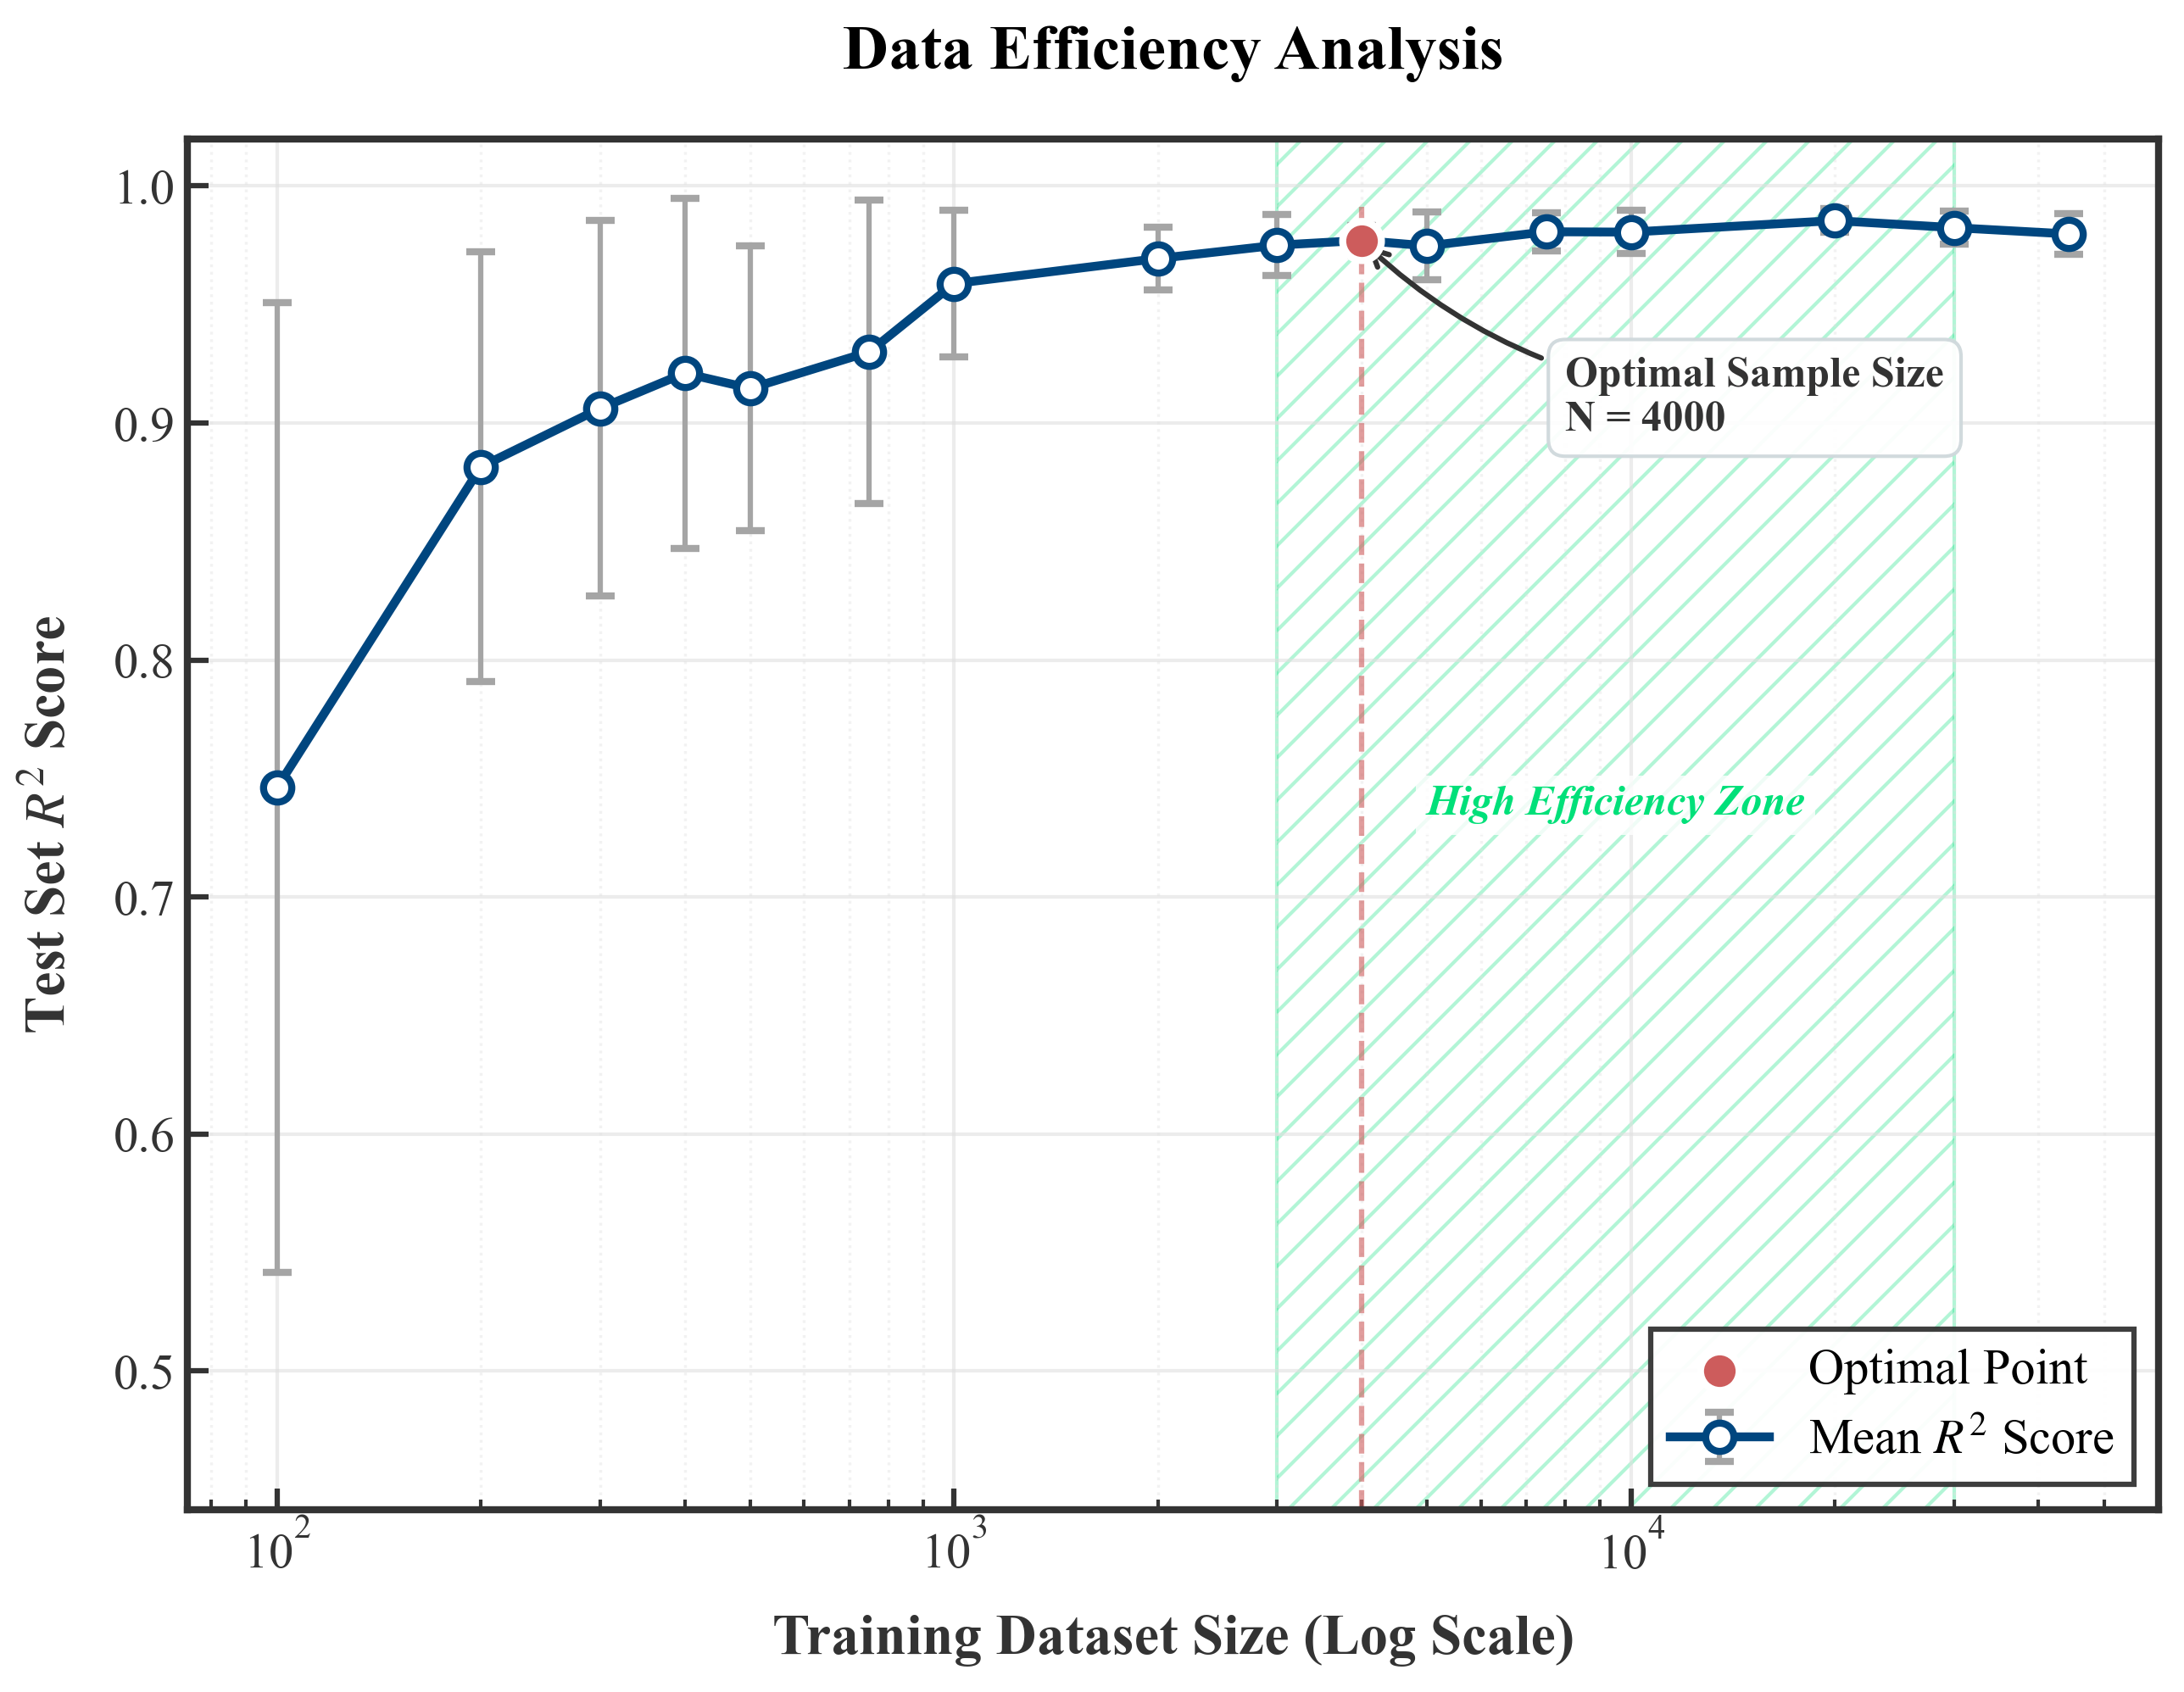

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.ticker as ticker
from viz_config import VizConfig

# ==========================================
# 0. 全局配置与风格设置
# ==========================================
# 应用统一的配色和样式配置 (viz_config.py)
VizConfig.set_style()

# 引用配置中的字号常量
TITLE_SIZE = VizConfig.TITLE_SIZE
LABEL_SIZE = VizConfig.LABEL_SIZE
TICK_SIZE = VizConfig.TICK_SIZE
LEGEND_SIZE = VizConfig.LEGEND_SIZE

# 路径设置
DATA_SUBDIR = "Data_Efficiency_Results"
CSV_NAME = "Data_Efficiency_Curve.csv"
FULL_PATH = os.path.join(DATA_SUBDIR, CSV_NAME)

# 确保输出目录存在
if not os.path.exists(DATA_SUBDIR):
    os.makedirs(DATA_SUBDIR)

# ==========================================
# 1. 数据读取 (Data Loading)
# ==========================================
print(f"Reading data: {FULL_PATH}")

if not os.path.exists(FULL_PATH):
    print(f"Warning: {FULL_PATH} not found. Using dummy data.")
    # 构造示例数据 (如果文件不存在)
    # Training_Size: 训练集大小
    # Mean_R2: 测试集 R2 均值
    # Std_R2: 测试集 R2 标准差 (用于误差棒)
    data = {'Training_Size': [100, 500, 1000, 2000, 4000, 10000, 20000],
            'Mean_R2': [0.6, 0.8, 0.9, 0.95, 0.97, 0.98, 0.985],
            'Std_R2': [0.1, 0.08, 0.05, 0.03, 0.02, 0.01, 0.01]}
    df = pd.DataFrame(data)
else:
    df = pd.read_csv(FULL_PATH)

# 按训练集大小排序，确保连线正确
df = df.sort_values('Training_Size')
x = df['Training_Size'].values
y = df['Mean_R2'].values
yerr = df['Std_R2'].values

# ==========================================
# 2. 数据分析与关键点计算
# ==========================================
max_r2 = np.max(y)
max_idx = np.argmax(y)

# 设定阈值寻找"最佳效率点" (Optimal Point)
# 定义为达到最大 R2 的 99% 时的最小样本量
threshold = max_r2 * 0.99
optimal_indices = np.where(y >= threshold)[0]
# 选取满足阈值条件的第一个点 (即样本量最小的点)
best_idx = optimal_indices[0] if len(optimal_indices) > 0 else max_idx
best_size = x[best_idx]
best_r2 = y[best_idx]

# 定义"高效率区域" (High Efficiency Zone) 的 X 轴范围
# 范围设定为最佳点的前一个点到最大值的后一个点 (或基于比例)
zone_min = x[max(0, best_idx - 1)] if best_idx > 0 else best_size * 0.5
zone_max = x[min(len(x)-1, max_idx + 1)] if max_idx < len(x)-1 else x[max_idx] * 1.5

# ==========================================
# 3. 绘图 (Figure 8: Data Efficiency)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 3.1 颜色定义 - 使用 VizConfig 统一配置
COLOR_MAIN = VizConfig.COLOR_MAIN       # 主曲线颜色 (深蓝)
COLOR_ERROR = VizConfig.COLOR_SECONDARY # 误差棒颜色 (灰色)
COLOR_OPTIMAL = VizConfig.COLOR_HIGHLIGHT # 最佳点颜色 (红色)
COLOR_HATCH = VizConfig.COLOR_SUCCESS   # 高效率区域颜色 (绿色)

# 3.2 绘制高效率区域 (High Efficiency Zone)
# 使用带斜线 (hatch='//') 的矩形区域标注
ax.axvspan(zone_min, zone_max, 
           facecolor='none',       # 背景透明
           hatch='//',             # 斜线填充
           edgecolor=COLOR_HATCH,  # 斜线颜色
           alpha=0.3,              # 透明度
           zorder=0)               # 置于最底层

# 计算Y轴显示范围
y_min_val = min(y - yerr)
y_lower = max(0, y_min_val - 0.1)
ax.set_ylim(y_lower, 1.02)

# 添加区域文字标注 "High Efficiency Zone"
# Log scale geometric center: 对数坐标下的几何中心
zone_center = np.sqrt(zone_min * zone_max) 
# transform=ax.get_xaxis_transform(): x 使用数据坐标，y 使用轴相对坐标 (0-1)
ax.text(zone_center, 0.05, "High Efficiency Zone", 
        transform=ax.get_xaxis_transform(), # y=0.05 表示底部向上 5% 的位置
        ha='center', va='bottom', fontsize=12, fontweight='bold', 
        color=COLOR_HATCH, style='italic', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

# 3.3 绘制误差棒曲线
# 使用半对数坐标系 (x轴为对数)
ax.errorbar(x, y, yerr=yerr, fmt='-o', markersize=8, linewidth=2.5, capsize=4,
             color=COLOR_MAIN, ecolor=COLOR_ERROR, elinewidth=1.5, 
             markerfacecolor='white', markeredgecolor=COLOR_MAIN, 
             markeredgewidth=2, label='Mean $R^2$ Score', zorder=3)

# 3.4 标记最佳效率点 (Optimal Point)
ax.scatter(best_size, best_r2, s=120, color=COLOR_OPTIMAL, alpha=1.0, 
          edgecolor='white', linewidth=2, zorder=4, label='Optimal Point')

# 绘制通过最佳点的垂直虚线
ax.axvline(x=best_size, color=COLOR_OPTIMAL, linestyle='--', linewidth=1.5, alpha=0.6, ymax=0.95, zorder=2)

# 3.5 添加标注文字 (Annotation)
# 自动调整标注框位置，避免遮挡曲线
xy_text_pos = (best_size * 2, best_r2 - 0.08) if best_r2 > 0.8 else (best_size * 2, best_r2 + 0.1)
ax.annotate(f'Optimal Sample Size\nN = {int(best_size)}', 
            xy=(best_size, best_r2), xytext=xy_text_pos,
            arrowprops=dict(arrowstyle="->", color=VizConfig.COLOR_AXIS, lw=1.5, connectionstyle="arc3,rad=-0.2"),
            fontsize=12, color=VizConfig.COLOR_AXIS, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#cfd8dc", alpha=0.95))

# ==========================================
# 4. 坐标轴与边框美化
# ==========================================
# 设置 X 轴为对数刻度
ax.set_xscale('log')

# 设置轴标签与标题
ax.set_xlabel("Training Dataset Size (Log Scale)", fontsize=LABEL_SIZE, fontweight='bold', labelpad=10)
ax.set_ylabel(r"Test Set $R^2$ Score", fontsize=LABEL_SIZE, fontweight='bold', labelpad=10)
ax.set_title("Data Efficiency Analysis", fontsize=TITLE_SIZE, pad=20, fontweight='bold')

# 网格设置
ax.grid(True, which="major", linestyle='-', alpha=0.6, color=VizConfig.COLOR_GRID, linewidth=1)
ax.grid(True, which="minor", linestyle=':', alpha=0.4, color=VizConfig.COLOR_GRID, linewidth=0.8)

# 边框设置 (加粗所有边框)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)
    spine.set_color(VizConfig.COLOR_AXIS)

# 刻度设置 (向内刻度)
ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE, length=6, width=1.5, colors=VizConfig.COLOR_AXIS, direction='in')
ax.tick_params(axis='both', which='minor', length=3, width=1, colors=VizConfig.COLOR_AXIS, direction='in')

# 图例设置
legend = ax.legend(fontsize=LEGEND_SIZE, loc='lower right', frameon=True, edgecolor=VizConfig.COLOR_AXIS, fancybox=False)
legend.get_frame().set_linewidth(1.5)

# ==========================================
# 5. 保存输出
# ==========================================
plt.tight_layout()
output_path = os.path.join(DATA_SUBDIR, "8.pdf")
# 保存高分辨率 PDF
plt.savefig(output_path, dpi=VizConfig.DPI, bbox_inches='tight', pad_inches=0.1) 

print(f"Saved refined plot to {output_path}")
plt.show()